In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data/x_train_final.csv")
df = df.drop(columns=["Unnamed: 0", "Unnamed: 0.1"])
df.head()

,train,gare,date,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4
0,VBXNMF,KYF,2023-04-03,8.0,0.0,0.0,1.0,-3.0,-1.0,-2.0
1,VBXNMF,JLR,2023-04-03,9.0,0.0,0.0,0.0,1.0,0.0,1.0
2,VBXNMF,EOH,2023-04-03,10.0,-1.0,0.0,0.0,-1.0,0.0,0.0
3,VBXNMF,VXY,2023-04-03,11.0,-1.0,-1.0,0.0,2.0,-2.0,0.0
4,VBXNMF,OCB,2023-04-03,12.0,-1.0,-1.0,-1.0,-1.0,3.0,2.0


In [47]:
df["gare"].value_counts()


gare
JLR    31643
KYF    29737
OCB    29230
ZHN    28521
VXY    27842
       ...  
UPZ       36
YEG       25
PDG       13
NIJ       11
TXR        6
Name: count, Length: 84, dtype: int64

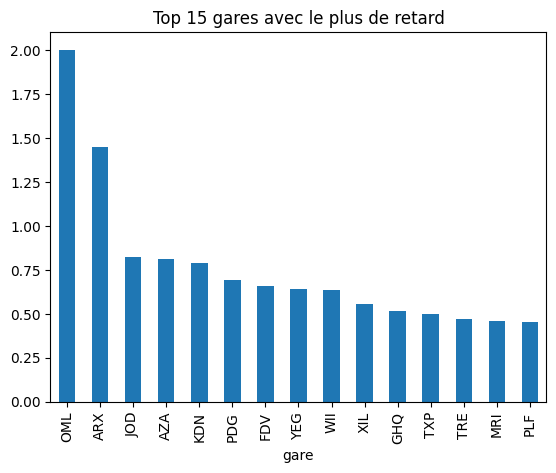

In [37]:
df.groupby("gare")["p2q0"].mean() \
  .sort_values(ascending=False) \
  .head(15) \
  .plot(kind="bar")

plt.title("Top 15 gares avec le plus de retard")
plt.show()

arret
 8.000     35571
 9.000     35021
 10.000    34821
 11.000    34265
 12.000    34151
 13.000    33174
 16.000    32131
 15.000    31385
 17.000    31283
 18.000    30580
 14.000    30435
 19.000    29205
 20.000    28093
 21.000    26400
 22.000    26291
 23.000    26121
 26.000    24313
 24.000    23839
 25.000    23677
 27.000    20217
 30.000    16581
 29.000    15773
 28.000    14529
 31.000     6700
 34.000     5968
 32.000     4133
 38.000     3821
 33.000     3770
 35.000     3746
 37.000      821
 7.000       266
 36.000      122
 41.000       50
 40.000        5
 39.000        4
-1.027         1
 42.000        1
Name: count, dtype: int64

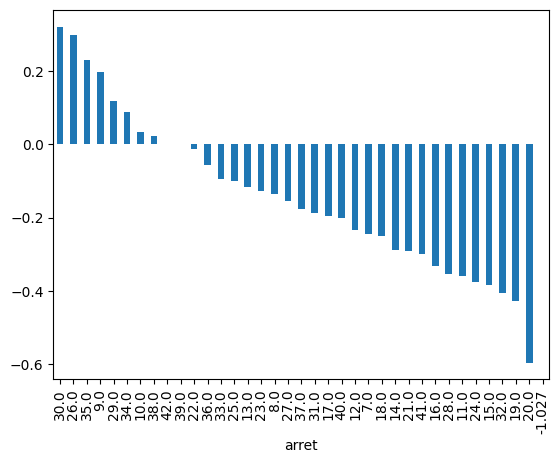

In [87]:
df.groupby("arret")["p2q0"].mean().sort_values(ascending=False).plot(kind="bar")
df["arret"].value_counts()

Text(0.5, 1.0, "Top 15 gares pour l'arrêt 8")

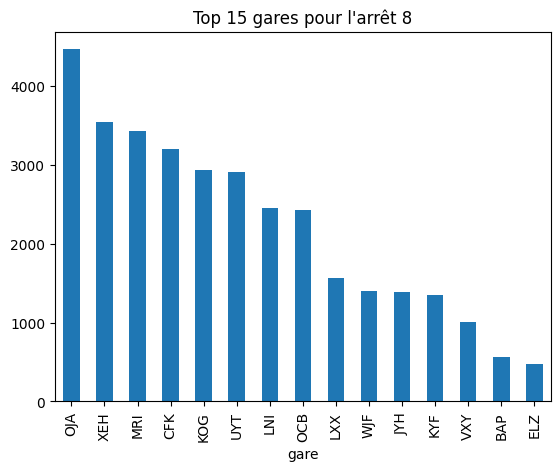

In [83]:
df_arret = df[df["arret"] == 8]

df_arret["gare"].value_counts().head(15).plot(kind="bar")
plt.title("Top 15 gares pour l'arrêt 8")

In [80]:
df[(df["train"] == "PBYUMJ") & (df["arret"] == 8)]

,train,gare,date,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4
98689,PBYUMJ,OJA,2023-05-09,8.0,0.0,0.0,0.0,1.0,0.0,0.0
236387,PBYUMJ,CFK,2023-06-06,8.0,-1.0,0.0,0.0,0.0,-2.0,-1.0


## On veut mapper les gares 

# Algo de con:

  Initialisation:  
    Soit le train T qui part de l'arret n°8 depuis la gare G1, on regarde le même train a l'arret 9 et on trace un trait entre G1 et G2
    
    On prend Un train T sur une unique date et on regarde les gares qu'il visite ordonné par ordre croissant de l'arret

In [86]:
# Paramètres
train_T = "VBXNMF"           # ton train
date_D = "2023-04-03"        # la date choisie

# Filtrer pour ce train et cette date
df_train_date = df[(df["train"] == train_T) & (df["date"] == date_D)]

# Trier par ordre croissant d'arrêt
df_train_date = df_train_date.sort_values(by="arret")

# Liste des gares dans l'ordre
gares_ordonnees = list(df_train_date["gare"])

# Afficher le résultat
print(gares_ordonnees)

['KYF', 'JLR', 'EOH', 'VXY', 'OCB']


In [ ]:
df.isna().sum()[df.isna().sum() > 0]

p2q0    1
dtype: int64

In [104]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error

x_train_df = pd.read_csv("data/x_train_final.csv")
y_train_df = pd.read_csv("data/y_train_final.csv")
x_test_df = pd.read_csv("data/x_test_final.csv")

df = x_train_df.merge(y_train_df, on="Unnamed: 0")

df = df.drop(columns=["Unnamed: 0.1"], errors="ignore")
x_test_clean = x_test_df.drop(columns=["Unnamed: 0.1"], errors="ignore")

df["date"] = pd.to_datetime(df["date"])
x_test_clean["date"] = pd.to_datetime(x_test_clean["date"])

for col in ["train", "gare"]:
    le = LabelEncoder()
    all_values = pd.concat([df[col], x_test_clean[col]], axis=0).astype(str)
    le.fit(all_values)
    df[col] = le.transform(df[col].astype(str))
    x_test_clean[col] = le.transform(x_test_clean[col].astype(str))

features = [
    "train",
    "gare",
    "arret",
    "p2q0",
    "p3q0",
    "p4q0",
    "p0q2",
    "p0q3",
    "p0q4",
]

target = "p0q0"

X_train = df[features]
y_train = df[target]

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)



X_test = x_test_clean[features]
test_preds = rf_model.predict(X_test)

submission = pd.DataFrame({
    "Unnamed: 0": x_test_df["Unnamed: 0"],
    "p0q0": test_preds
})

submission.to_csv("submission_rf.csv", index=False)

print(submission.head())

Fichier créé : submission_rf.csv
   Unnamed: 0      p0q0
0           0 -1.674136
1           1 -0.111668
2           2  0.280238
3           3 -0.606038
4           4 -0.372826


In [103]:
y_train_pred = rf_model.predict(X_train)

mae_train = mean_absolute_error(y_train, y_train_pred)

print("MAE train:", mae_train)

MAE train: 0.8056958325916964
